# Notebook 15: Deep Q-Networks (DQN)

**Series:** Reinforcement Learning Basics (15/20)

---

## 1. The Problem

Q-Learning with neural networks naively **diverges** due to:
1. **Correlated samples:** Sequential data is highly correlated
2. **Non-stationary targets:** Target changes as Q-network updates
3. **Function approximation + bootstrapping + off-policy** = The Deadly Triad

## 2. DQN Innovations

### Experience Replay
Store transitions $(s, a, r, s', done)$ in buffer $\mathcal{D}$, sample random minibatches.
- Breaks temporal correlations
- Reuses data (sample efficiency)
- Each transition can be used in many updates

### Target Network
Use a **separate frozen network** $Q(s, a; \theta^-)$ for computing targets:

$$y_i = r + \gamma \max_{a'} Q(s', a'; \theta^-)$$

$\theta^-$ is updated periodically: $\theta^- \leftarrow \theta$ every $C$ steps.

## 3. DQN Loss

$$L(\theta) = \mathbb{E}_{(s,a,r,s') \sim \mathcal{D}} \left[ \Big( y_i - Q(s, a; \theta) \Big)^2 \right]$$

## 4. Huber Loss (Smooth L1)

$$L_\delta(a) = \begin{cases} \frac{1}{2}a^2 & \text{if } |a| \leq \delta \\ \delta(|a| - \frac{1}{2}\delta) & \text{otherwise} \end{cases}$$

More robust to outliers than MSE.

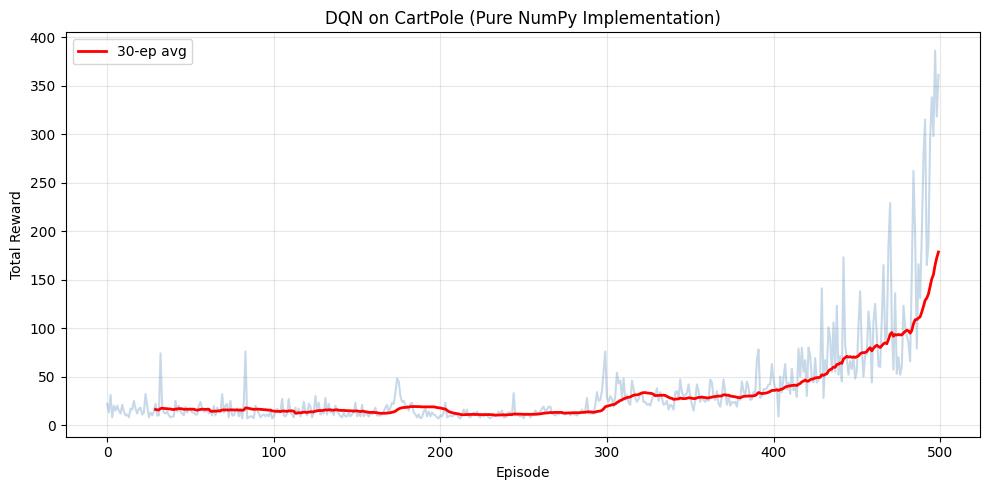

Last 50 avg: 145.4


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import deque
import random

# CartPole environment
class CartPole:
    def __init__(self):
        self.gravity=9.8;self.masscart=1.0;self.masspole=0.1;self.total_mass=1.1
        self.length=0.5;self.polemass_length=0.05;self.force_mag=10.0;self.tau=0.02
        self.theta_threshold=12*np.pi/180;self.x_threshold=2.4
    def reset(self):
        self.state=np.random.uniform(-0.05,0.05,4);return self.state.copy()
    def step(self,action):
        x,xd,th,thd=self.state;f=self.force_mag if action==1 else -self.force_mag
        ct,st=np.cos(th),np.sin(th)
        tmp=(f+self.polemass_length*thd**2*st)/self.total_mass
        thacc=(self.gravity*st-ct*tmp)/(self.length*(4/3-self.masspole*ct**2/self.total_mass))
        xacc=tmp-self.polemass_length*thacc*ct/self.total_mass
        self.state=np.array([x+self.tau*xd,xd+self.tau*xacc,th+self.tau*thd,thd+self.tau*thacc])
        done=abs(self.state[0])>self.x_threshold or abs(self.state[2])>self.theta_threshold
        return self.state.copy(),1.0 if not done else 0.0,done

# ============================================
# Simple DQN (no PyTorch — pure numpy 2-layer network)
# ============================================
class ReplayBuffer:
    def __init__(self, capacity=10000):
        self.buffer = deque(maxlen=capacity)
    def push(self, s, a, r, s_next, done):
        self.buffer.append((s, a, r, s_next, done))
    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        s, a, r, sn, d = zip(*batch)
        return np.array(s), np.array(a), np.array(r), np.array(sn), np.array(d)
    def __len__(self):
        return len(self.buffer)

class SimpleQNetwork:
    def __init__(self, input_dim=4, hidden_dim=64, output_dim=2, lr=0.001):
        self.W1 = np.random.randn(input_dim, hidden_dim) * 0.1
        self.b1 = np.zeros(hidden_dim)
        self.W2 = np.random.randn(hidden_dim, output_dim) * 0.1
        self.b2 = np.zeros(output_dim)
        self.lr = lr

    def forward(self, x):
        self.z1 = x @ self.W1 + self.b1
        self.h1 = np.maximum(0, self.z1)  # ReLU
        self.out = self.h1 @ self.W2 + self.b2
        return self.out

    def predict(self, state):
        return self.forward(state.reshape(1, -1))[0]

    def update(self, states, targets, actions):
        batch_size = len(states)
        # Forward
        out = self.forward(states)
        # Loss gradient: d/dout only for taken actions
        d_out = np.zeros_like(out)
        for i in range(batch_size):
            d_out[i, actions[i]] = 2 * (out[i, actions[i]] - targets[i]) / batch_size
        # Backward
        d_W2 = self.h1.T @ d_out
        d_b2 = d_out.sum(axis=0)
        d_h1 = d_out @ self.W2.T
        d_z1 = d_h1 * (self.z1 > 0)
        d_W1 = states.T @ d_z1
        d_b1 = d_z1.sum(axis=0)
        # Update
        self.W1 -= self.lr * d_W1; self.b1 -= self.lr * d_b1
        self.W2 -= self.lr * d_W2; self.b2 -= self.lr * d_b2

    def copy_from(self, other):
        self.W1 = other.W1.copy(); self.b1 = other.b1.copy()
        self.W2 = other.W2.copy(); self.b2 = other.b2.copy()

# Train DQN
env = CartPole()
q_net = SimpleQNetwork(lr=0.001)
target_net = SimpleQNetwork()
target_net.copy_from(q_net)
buffer = ReplayBuffer(10000)
gamma = 0.99; epsilon = 1.0; eps_decay = 0.995; eps_min = 0.01
batch_size = 64; target_update = 10
episode_rewards = []

for ep in range(500):
    state = env.reset(); total_reward = 0
    for t in range(500):
        if np.random.random() < epsilon:
            action = np.random.randint(2)
        else:
            q_vals = q_net.predict(state)
            action = np.argmax(q_vals)
        next_state, reward, done = env.step(action)
        buffer.push(state, action, reward, next_state, done)
        total_reward += reward
        state = next_state

        if len(buffer) >= batch_size:
            s, a, r, sn, d = buffer.sample(batch_size)
            q_next = target_net.forward(sn)
            targets = r + gamma * np.max(q_next, axis=1) * (1 - d)
            q_net.update(s, targets, a)

        if done: break

    epsilon = max(eps_min, epsilon * eps_decay)
    if ep % target_update == 0:
        target_net.copy_from(q_net)
    episode_rewards.append(total_reward)

plt.figure(figsize=(10, 5))
plt.plot(episode_rewards, alpha=0.3, color='steelblue')
w = 30
sm = np.convolve(episode_rewards, np.ones(w)/w, mode='valid')
plt.plot(range(w-1, len(episode_rewards)), sm, 'r-', linewidth=2, label=f'{w}-ep avg')
plt.xlabel('Episode'); plt.ylabel('Total Reward')
plt.title('DQN on CartPole (Pure NumPy Implementation)')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
plt.show()
print(f"Last 50 avg: {np.mean(episode_rewards[-50:]):.1f}")

## Summary

| Innovation | Purpose |
|-----------|---------|
| **Experience Replay** | Break correlations, reuse data |
| **Target Network** | Stable targets, prevent divergence |
| **Huber Loss** | Robustness to outliers |

**Next:** Notebook 16 — Double DQN & Dueling DQN